In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf


from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from pandas.api.types import is_datetime64_any_dtype


# 1. Data preprocessing

In [26]:
df = pd.read_csv("time_series_60min_singleindex.csv", delimiter=",")

In [27]:
df.shape

(50401, 300)

In [28]:
df.head()

,utc_timestamp,cet_cest_timestamp,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_price_day_ahead,AT_solar_generation_actual,AT_wind_onshore_generation_actual,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,...,SI_load_actual_entsoe_transparency,SI_load_forecast_entsoe_transparency,SI_solar_generation_actual,SI_wind_onshore_generation_actual,SK_load_actual_entsoe_transparency,SK_load_forecast_entsoe_transparency,SK_solar_generation_actual,SK_wind_onshore_generation_actual,UA_load_actual_entsoe_transparency,UA_load_forecast_entsoe_transparency
0,2014-12-31T23:00:00Z,2015-01-01T00:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01T00:00:00Z,2015-01-01T01:00:00+0100,5946.0,6701.0,35.0,NaN,69.0,9484.0,9897.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-01T01:00:00Z,2015-01-01T02:00:00+0100,5726.0,6593.0,45.0,NaN,64.0,9152.0,9521.0,NaN,...,1045.47,816.0,NaN,1.17,2728.0,2860.0,3.8,NaN,NaN,NaN
3,2015-01-01T02:00:00Z,2015-01-01T03:00:00+0100,5347.0,6482.0,41.0,NaN,65.0,8799.0,9135.0,NaN,...,1004.79,805.0,NaN,1.04,2626.0,2810.0,3.8,NaN,NaN,NaN
4,2015-01-01T03:00:00Z,2015-01-01T04:00:00+0100,5249.0,6454.0,38.0,NaN,64.0,8567.0,8909.0,NaN,...,983.79,803.0,NaN,1.61,2618.0,2780.0,3.8,NaN,NaN,NaN


#### Convert timestamps and create time features


In [29]:
# Convert timestamps utc and cet_cest
df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"], utc=True)
df["cet_cest_timestamp"] = df["utc_timestamp"].dt.tz_convert("Europe/Berlin")

# create time features
df["hour"] = df["cet_cest_timestamp"].dt.hour
df["dayofweek"] = df["cet_cest_timestamp"].dt.dayofweek

## 1.1 Select columns for new dataset

In [30]:
#  Select columns
df_selected = df[
    [
        "utc_timestamp",
        "cet_cest_timestamp",
        "hour",
        "dayofweek",
        "DE_load_actual_entsoe_transparency",
        "DE_load_forecast_entsoe_transparency",
        "DE_solar_capacity",
        "DE_solar_generation_actual",
        "DE_wind_capacity",
        "DE_wind_generation_actual",
        "DE_LU_price_day_ahead",
    ]
].copy()

In [31]:
# Set target variable
target = "DE_LU_price_day_ahead"

In [32]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50401 entries, 0 to 50400
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype                        
---  ------                                --------------  -----                        
 0   utc_timestamp                         50401 non-null  datetime64[ns, UTC]          
 1   cet_cest_timestamp                    50401 non-null  datetime64[ns, Europe/Berlin]
 2   hour                                  50401 non-null  int32                        
 3   dayofweek                             50401 non-null  int32                        
 4   DE_load_actual_entsoe_transparency    50400 non-null  float64                      
 5   DE_load_forecast_entsoe_transparency  50376 non-null  float64                      
 6   DE_solar_capacity                     43800 non-null  float64                      
 7   DE_solar_generation_actual            50297 non-null  float64                      
 

-> There are many na values in dataset

In [33]:
df_selected

,utc_timestamp,cet_cest_timestamp,hour,dayofweek,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_capacity,DE_solar_generation_actual,DE_wind_capacity,DE_wind_generation_actual,DE_LU_price_day_ahead
0,2014-12-31 23:00:00+00:00,2015-01-01 00:00:00+01:00,0,3,NaN,NaN,37248.0,NaN,27913.0,NaN,NaN
1,2015-01-01 00:00:00+00:00,2015-01-01 01:00:00+01:00,1,3,41151.0,39723.0,37248.0,NaN,27913.0,8852.0,NaN
2,2015-01-01 01:00:00+00:00,2015-01-01 02:00:00+01:00,2,3,40135.0,38813.0,37248.0,NaN,27913.0,9054.0,NaN
3,2015-01-01 02:00:00+00:00,2015-01-01 03:00:00+01:00,3,3,39106.0,38490.0,37248.0,NaN,27913.0,9070.0,NaN
4,2015-01-01 03:00:00+00:00,2015-01-01 04:00:00+01:00,4,3,38765.0,38644.0,37248.0,NaN,27913.0,9163.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
50396,2020-09-30 19:00:00+00:00,2020-09-30 21:00:00+02:00,21,2,57559.0,56708.0,NaN,0.0,NaN,10654.0,49.92
50397,2020-09-30 20:00:00+00:00,2020-09-30 22:00:00+02:00,22,2,54108.0,53270.0,NaN,0.0,NaN,11836.0,42.79
50398,2020-09-30 21:00:00+00:00,2020-09-30 23:00:00+02:00,23,2,49845.0,49239.0,NaN,0.0,NaN,12168.0,35.02
50399,2020-09-30 22:00:00+00:00,2020-10-01 00:00:00+02:00,0,3,46886.0,46620.0,NaN,0.0,NaN,12533.0,34.40


## 1.2 Drop NA Value from Target Variable: DE_LU_price_day_ahead


In [34]:
df_drop_na = df_selected.dropna(subset=[target]).copy()


In [35]:
df_drop_na.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17540 entries, 32856 to 50399
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype                        
---  ------                                --------------  -----                        
 0   utc_timestamp                         17540 non-null  datetime64[ns, UTC]          
 1   cet_cest_timestamp                    17540 non-null  datetime64[ns, Europe/Berlin]
 2   hour                                  17540 non-null  int32                        
 3   dayofweek                             17540 non-null  int32                        
 4   DE_load_actual_entsoe_transparency    17540 non-null  float64                      
 5   DE_load_forecast_entsoe_transparency  17540 non-null  float64                      
 6   DE_solar_capacity                     10942 non-null  float64                      
 7   DE_solar_generation_actual            17540 non-null  float64                      
 8

-> Still have some na values in DE_solar_capacity and DE_wind_capacity

## 1.3 Sort values by utc_timestamp, check time continuity and time duplicate after removing missing data from DE_LU_price_day_ahead

In [36]:
### Sort values
df_drop_na = df_drop_na.sort_values("utc_timestamp").reset_index(drop=True)

In [37]:
### check time continueity and duplicates
full_range = pd.date_range(
    start=df_drop_na["utc_timestamp"].min(),
    end=df_drop_na["utc_timestamp"].max(),
    freq="h",
    tz="UTC"
)

missing_times = full_range.difference(df_drop_na["utc_timestamp"])
duplicates = df_drop_na[df_drop_na["utc_timestamp"].duplicated(keep=False)]

print("Start:", df_drop_na["utc_timestamp"].min())
print("End:", df_drop_na["utc_timestamp"].max())
print("Expected rows:", len(full_range))
print("Actual rows:", len(df_drop_na))
print("Missing timestamps:", len(missing_times))
print("Duplicate timestamps:", len(duplicates))
print("Continuous hourly series:", len(missing_times) == 0 and duplicates.empty)

print("\nMissing timestamps:")
print(missing_times)

Start: 2018-09-30 23:00:00+00:00
End: 2020-09-30 22:00:00+00:00
Expected rows: 17544
Actual rows: 17540
Missing timestamps: 4
Duplicate timestamps: 0
Continuous hourly series: False

Missing timestamps:
DatetimeIndex(['2019-03-31 02:00:00+00:00', '2019-03-31 03:00:00+00:00',
               '2020-03-29 02:00:00+00:00', '2020-03-29 03:00:00+00:00'],
              dtype='datetime64[ns, UTC]', freq=None)


-> There are 4 missing timestamps that were removed by dropna, that means the value of DE_LU_price_ahead in these 4 rows are missing

## 1.4 Add missing timestamps back to make it continuous


In [38]:
### The missing_rows from df_drop_na was extracted from df_selected to add back to df_drop_na
add_missing_rows = df_selected[
    df_selected["utc_timestamp"].isin(missing_times)
].copy()

print(add_missing_rows)

                  utc_timestamp        cet_cest_timestamp  hour  dayofweek  \
37203 2019-03-31 02:00:00+00:00 2019-03-31 04:00:00+02:00     4          6   
37204 2019-03-31 03:00:00+00:00 2019-03-31 05:00:00+02:00     5          6   
45939 2020-03-29 02:00:00+00:00 2020-03-29 04:00:00+02:00     4          6   
45940 2020-03-29 03:00:00+00:00 2020-03-29 05:00:00+02:00     5          6   

       DE_load_actual_entsoe_transparency  \
37203                             40193.0   
37204                             40404.0   
45939                             38827.0   
45940                             38325.0   

       DE_load_forecast_entsoe_transparency  DE_solar_capacity  \
37203                               38228.0            49114.0   
37204                               38205.0            49114.0   
45939                               41726.0                NaN   
45940                               41378.0                NaN   

       DE_solar_generation_actual  DE_wind_capacity 

In [39]:
#### Create new DataFrame with missing rows added back to df_drop_na
df_continuous = pd.concat(
    [df_drop_na, add_missing_rows],
    ignore_index=True
)

#### Sort again by time

In [40]:
df_continuous = df_continuous.sort_values("utc_timestamp").reset_index(drop=True)

#### Check everything again

In [41]:
full_range_check = pd.date_range(
    start=df_continuous["utc_timestamp"].min(),
    end=df_continuous["utc_timestamp"].max(),
    freq="h",
    tz="UTC"
)

missing_times_check = full_range_check.difference(df_continuous["utc_timestamp"])

duplicates_check = df_continuous[
    df_continuous["utc_timestamp"].duplicated(keep=False)
]

print("Start:", df_continuous["utc_timestamp"].min())
print("End:", df_continuous["utc_timestamp"].max())
print("Expected rows:", len(full_range_check))
print("Actual rows:", len(df_continuous))
print("Missing timestamps:", len(missing_times_check))
print("Duplicate timestamps:", len(duplicates_check))
print("Continuous hourly series:", len(missing_times_check) == 0 and duplicates_check.empty)

print("\nMissing timestamps after adding back:")
print(missing_times_check)

Start: 2018-09-30 23:00:00+00:00
End: 2020-09-30 22:00:00+00:00
Expected rows: 17544
Actual rows: 17544
Missing timestamps: 0
Duplicate timestamps: 0
Continuous hourly series: True

Missing timestamps after adding back:
DatetimeIndex([], dtype='datetime64[ns, UTC]', freq='h')


In [42]:
df_continuous.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype                        
---  ------                                --------------  -----                        
 0   utc_timestamp                         17544 non-null  datetime64[ns, UTC]          
 1   cet_cest_timestamp                    17544 non-null  datetime64[ns, Europe/Berlin]
 2   hour                                  17544 non-null  int32                        
 3   dayofweek                             17544 non-null  int32                        
 4   DE_load_actual_entsoe_transparency    17544 non-null  float64                      
 5   DE_load_forecast_entsoe_transparency  17544 non-null  float64                      
 6   DE_solar_capacity                     10944 non-null  float64                      
 7   DE_solar_generation_actual            17544 non-null  float64                      
 

## 1.5 Fill mising values

In [43]:
# Columns to fill with forward fill + backward fill for "DE_solar_capacity" and "DE_wind_capacity"
capacity = [
    "DE_solar_capacity",
    "DE_wind_capacity"
]

# Fill capacity columns
df_continuous[capacity] = (
    df_continuous[capacity]
    .ffill()
    .bfill()
) 

In [44]:
# Interpolate target column
df_continuous[target] = (
    df_continuous[target]
    .interpolate(method="linear")
)

In [45]:
# Check missing values after filling
print(df_continuous[
    [
        "DE_solar_capacity",
        "DE_wind_capacity",
        "DE_LU_price_day_ahead"
    ]
].isna().sum())

DE_solar_capacity        0
DE_wind_capacity         0
DE_LU_price_day_ahead    0
dtype: int64


In [46]:
df_continuous.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype                        
---  ------                                --------------  -----                        
 0   utc_timestamp                         17544 non-null  datetime64[ns, UTC]          
 1   cet_cest_timestamp                    17544 non-null  datetime64[ns, Europe/Berlin]
 2   hour                                  17544 non-null  int32                        
 3   dayofweek                             17544 non-null  int32                        
 4   DE_load_actual_entsoe_transparency    17544 non-null  float64                      
 5   DE_load_forecast_entsoe_transparency  17544 non-null  float64                      
 6   DE_solar_capacity                     17544 non-null  float64                      
 7   DE_solar_generation_actual            17544 non-null  float64                      
 

## 1.6 Check ACF

<Figure size 1200x600 with 0 Axes>

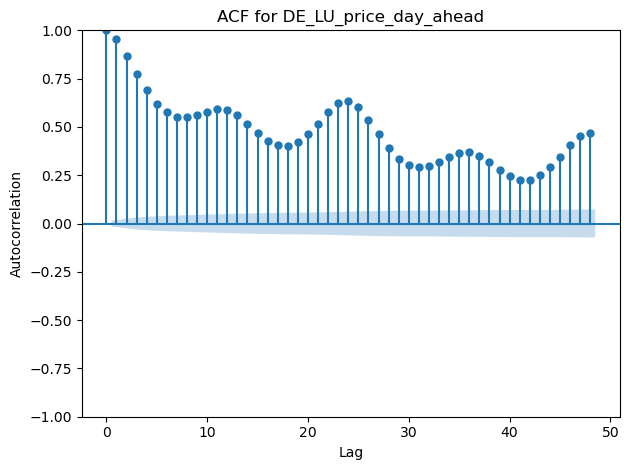

In [47]:
price_series = df_continuous["DE_LU_price_day_ahead"]
plt.figure(figsize=(12, 6))
plot_acf(price_series, lags=48, alpha=0.05)
plt.title("ACF for DE_LU_price_day_ahead")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

The electricity price series exhibits strong positive autocorrelation across multiple lags.

## 1.7 Preparation for building model

In [48]:
df_final = df_continuous.copy()

Hour 23 and hour 0 are close in real time,
but numerically 23 and 0 look far apart.

Cyclic encoding helps the model understand this.

In [49]:
# Hour cyclic encoding
df_final["hour_sin"] = np.sin(2 * np.pi * df_final["hour"] / 24)
df_final["hour_cos"] = np.cos(2 * np.pi * df_final["hour"] / 24)

# Day of week cyclic encoding
df_final["dayofweek_sin"] = np.sin(2 * np.pi * df_final["dayofweek"] / 7)
df_final["dayofweek_cos"] = np.cos(2 * np.pi * df_final ["dayofweek"] / 7)

In [50]:
# Lag features of target
df_final["price_lag_1h"] = df_final[target].shift(1)
df_final["price_lag_24h"] = df_final[target].shift(24)    # same hour previous day
df_final["price_lag_168h"] = df_final[target].shift(168)  # same hour last week 

In [51]:
df_final["price_rolling_mean_24h"] = (
    df_final[target]
    .shift(1)
    .rolling(window=24)
    .mean()
)

df_final["price_rolling_std_24h"] = (
    df_final[target]
    .shift(1)
    .rolling(window=24)
    .std()
)

In [52]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 20 columns):
 #   Column                                Non-Null Count  Dtype                        
---  ------                                --------------  -----                        
 0   utc_timestamp                         17544 non-null  datetime64[ns, UTC]          
 1   cet_cest_timestamp                    17544 non-null  datetime64[ns, Europe/Berlin]
 2   hour                                  17544 non-null  int32                        
 3   dayofweek                             17544 non-null  int32                        
 4   DE_load_actual_entsoe_transparency    17544 non-null  float64                      
 5   DE_load_forecast_entsoe_transparency  17544 non-null  float64                      
 6   DE_solar_capacity                     17544 non-null  float64                      
 7   DE_solar_generation_actual            17544 non-null  float64                      
 

### Drop rows created by lag/rolling features because they contain missing values, which needs past data

In [53]:
df_final = df_final.dropna().reset_index(drop=True)

In [54]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17376 entries, 0 to 17375
Data columns (total 20 columns):
 #   Column                                Non-Null Count  Dtype                        
---  ------                                --------------  -----                        
 0   utc_timestamp                         17376 non-null  datetime64[ns, UTC]          
 1   cet_cest_timestamp                    17376 non-null  datetime64[ns, Europe/Berlin]
 2   hour                                  17376 non-null  int32                        
 3   dayofweek                             17376 non-null  int32                        
 4   DE_load_actual_entsoe_transparency    17376 non-null  float64                      
 5   DE_load_forecast_entsoe_transparency  17376 non-null  float64                      
 6   DE_solar_capacity                     17376 non-null  float64                      
 7   DE_solar_generation_actual            17376 non-null  float64                      
 

### define again columns because datetime columns can not be used directly in xgboost

In [55]:
feature_cols = [
    "hour",
    "dayofweek",
    "hour_sin",
    "hour_cos",
    "dayofweek_sin",
    "dayofweek_cos",

    "DE_load_actual_entsoe_transparency",
    "DE_load_forecast_entsoe_transparency",
    "DE_solar_capacity",
    "DE_solar_generation_actual",
    "DE_wind_capacity",
    "DE_wind_generation_actual",

    "price_lag_1h",
    "price_lag_24h",
    "price_lag_168h",
    "price_rolling_mean_24h",
    "price_rolling_std_24h"
]

X = df_final[feature_cols]
y = df_final[target]
time = df_final["utc_timestamp"]

## 1.8 Extracting preprocessed dataset 

In [56]:
df_final.to_csv(
    "df_final_60min.csv",
    index=False
)

# 2. Preview data analysis

## 2.1 Plot Eclectricity price over time

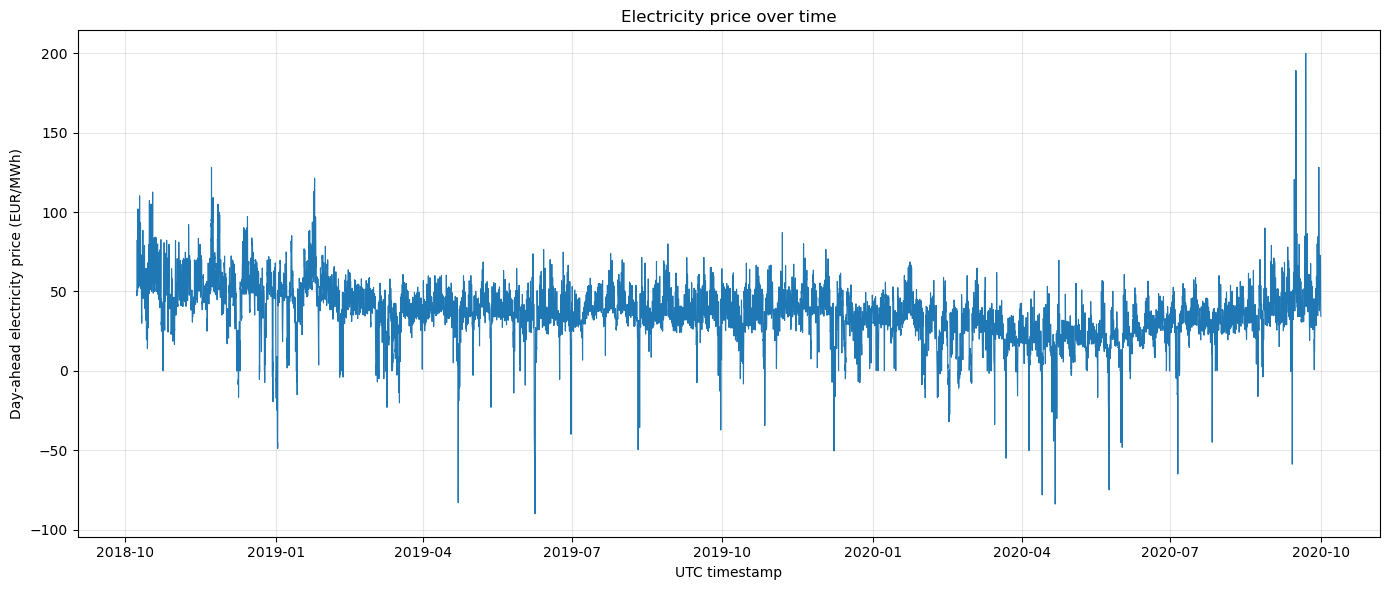

In [57]:
df_plot = df_final.copy()

# Plot time series
plt.figure(figsize=(14, 6))

plt.plot(
    df_plot["utc_timestamp"],
    df_plot["DE_LU_price_day_ahead"],
    linewidth=0.8
)

plt.title("Electricity price over time")
plt.xlabel("UTC timestamp")
plt.ylabel("Day-ahead electricity price (EUR/MWh)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2.2 Average electricity price over time

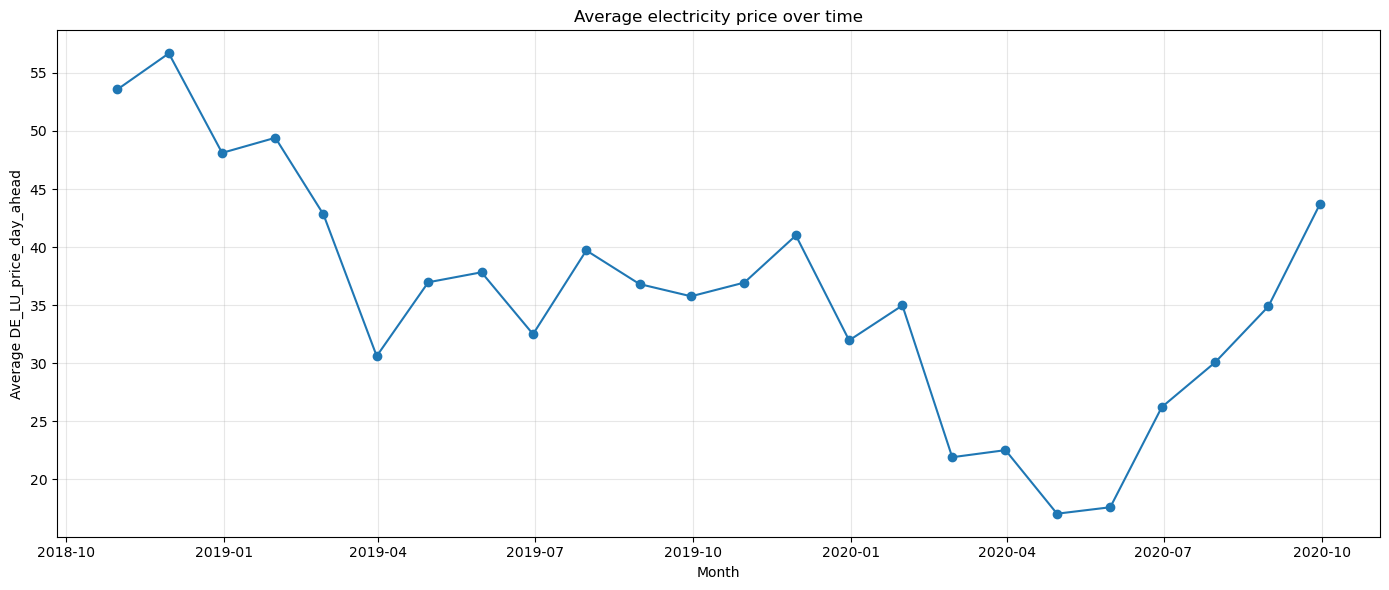

In [58]:
# Plot average price over time (monthly average)
df_plot = df_plot.set_index("utc_timestamp")

monthly_price = (
    df_plot["DE_LU_price_day_ahead"]
    .resample("ME")   # Group observations by calendar month
    .mean()           # Calculate the monthly average price
    .reset_index()    # Convert utc_timestamp back into a normal column
)

plt.figure(figsize=(14, 6))
plt.plot(
    monthly_price["utc_timestamp"],
    monthly_price["DE_LU_price_day_ahead"],
    marker="o",
    linewidth=1.5
)
plt.title("Average electricity price over time")
plt.xlabel("Month")
plt.ylabel("Average DE_LU_price_day_ahead")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2.3 Demand and supply plot

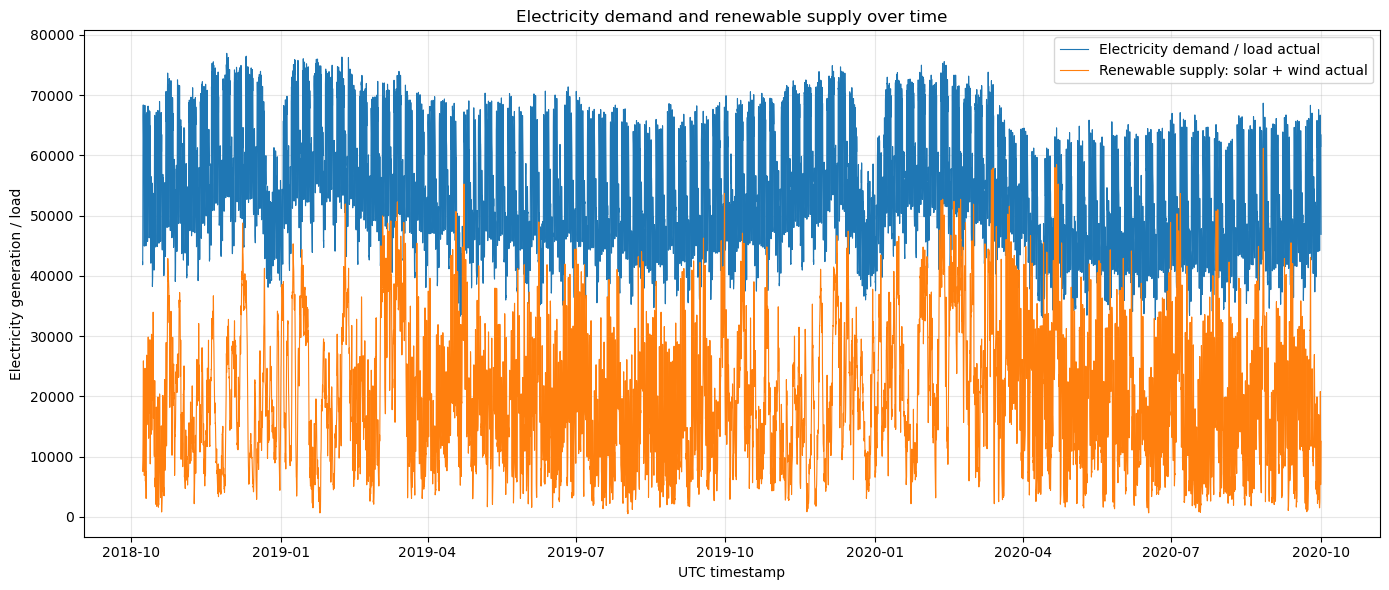

In [59]:
# Make a copy
df_plot = df_final.copy()

# Ensure utc_timestamp is datetime
if not is_datetime64_any_dtype(df_plot["utc_timestamp"]):
    df_plot["utc_timestamp"] = pd.to_datetime(
        df_plot["utc_timestamp"],
        utc=True,
        errors="coerce"
    )

# Define demand and renewable supply columns
demand_col = "DE_load_actual_entsoe_transparency"
solar_col = "DE_solar_generation_actual"
wind_col = "DE_wind_generation_actual"

# Drop rows with missing values in required columns
df_plot = df_plot.dropna(
    subset=[
        "utc_timestamp",
        demand_col,
        solar_col,
        wind_col
    ]
).sort_values("utc_timestamp")

# Create renewable supply column
df_plot["renewable_supply_solar_wind"] = (
    df_plot[solar_col] + df_plot[wind_col]
)

# Plot demand and renewable supply
plt.figure(figsize=(14, 6))

plt.plot(
    df_plot["utc_timestamp"],
    df_plot[demand_col],
    label="Electricity demand / load actual",
    linewidth=0.8
)

plt.plot(
    df_plot["utc_timestamp"],
    df_plot["renewable_supply_solar_wind"],
    label="Renewable supply: solar + wind actual",
    linewidth=0.8
)

plt.title("Electricity demand and renewable supply over time")
plt.xlabel("UTC timestamp")
plt.ylabel("Electricity generation / load")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

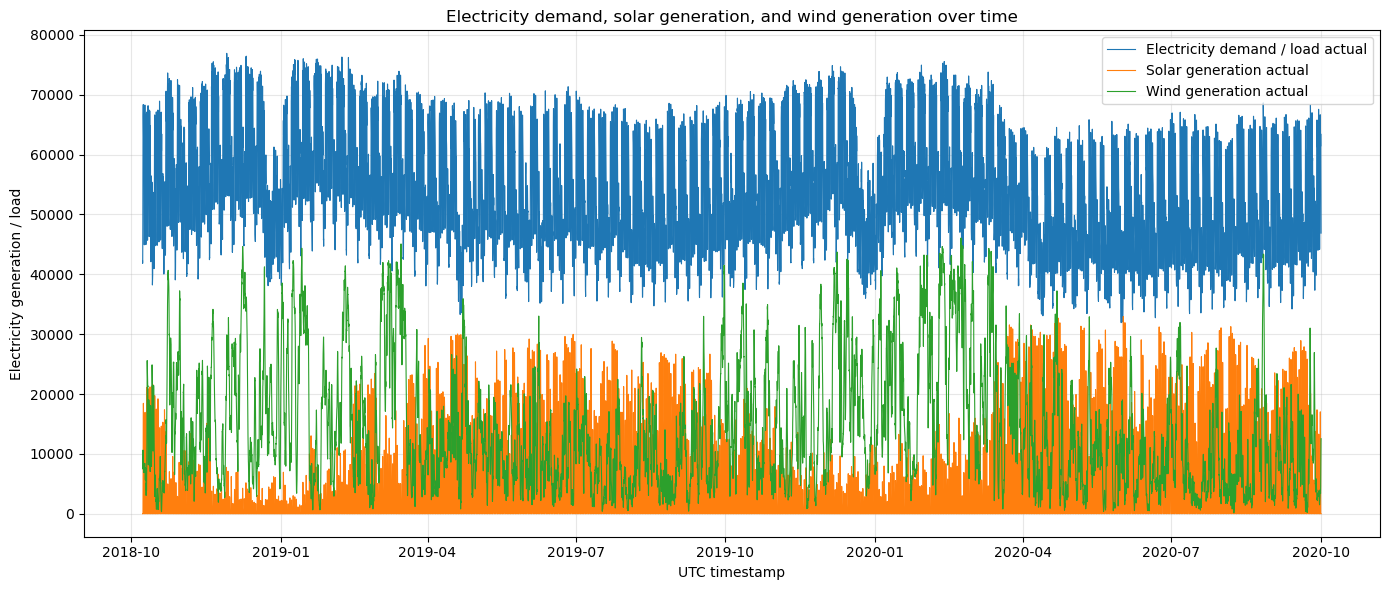

In [60]:
### Wind and solar seperate
plt.figure(figsize=(14, 6))

plt.plot(
    df_plot["utc_timestamp"],
    df_plot[demand_col],
    label="Electricity demand / load actual",
    linewidth=0.8
)

plt.plot(
    df_plot["utc_timestamp"],
    df_plot[solar_col],
    label="Solar generation actual",
    linewidth=0.8
)

plt.plot(
    df_plot["utc_timestamp"],
    df_plot[wind_col],
    label="Wind generation actual",
    linewidth=0.8
)

plt.title("Electricity demand, solar generation, and wind generation over time")
plt.xlabel("UTC timestamp")
plt.ylabel("Electricity generation / load")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2.4 Average electricity demand a day

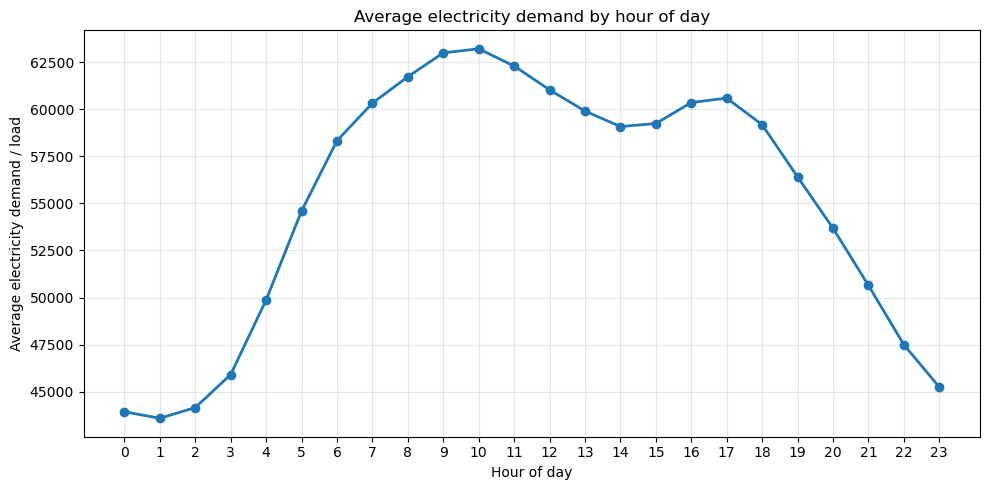

In [61]:
# Make a copy
df_plot = df_final.copy()

# Ensure utc_timestamp is datetime
if not is_datetime64_any_dtype(df_plot["utc_timestamp"]):
    df_plot["utc_timestamp"] = pd.to_datetime(
        df_plot["utc_timestamp"],
        utc=True,
        errors="coerce"
    )

# Demand column
demand_col = "DE_load_actual_entsoe_transparency"

# Drop missing values
df_plot = df_plot.dropna(subset=["utc_timestamp", demand_col])

# Extract hour from utc_timestamp
df_plot["hour"] = df_plot["utc_timestamp"].dt.hour

# Calculate average electricity demand for each hour of the day
avg_demand_by_hour = (
    df_plot
    .groupby("hour")[demand_col]
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(10, 5))

plt.plot(
    avg_demand_by_hour["hour"],
    avg_demand_by_hour[demand_col],
    marker="o",
    linewidth=2
)

plt.title("Average electricity demand by hour of day")
plt.xlabel("Hour of day")
plt.ylabel("Average electricity demand / load")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2.5 Average monthly solar vs wind generation

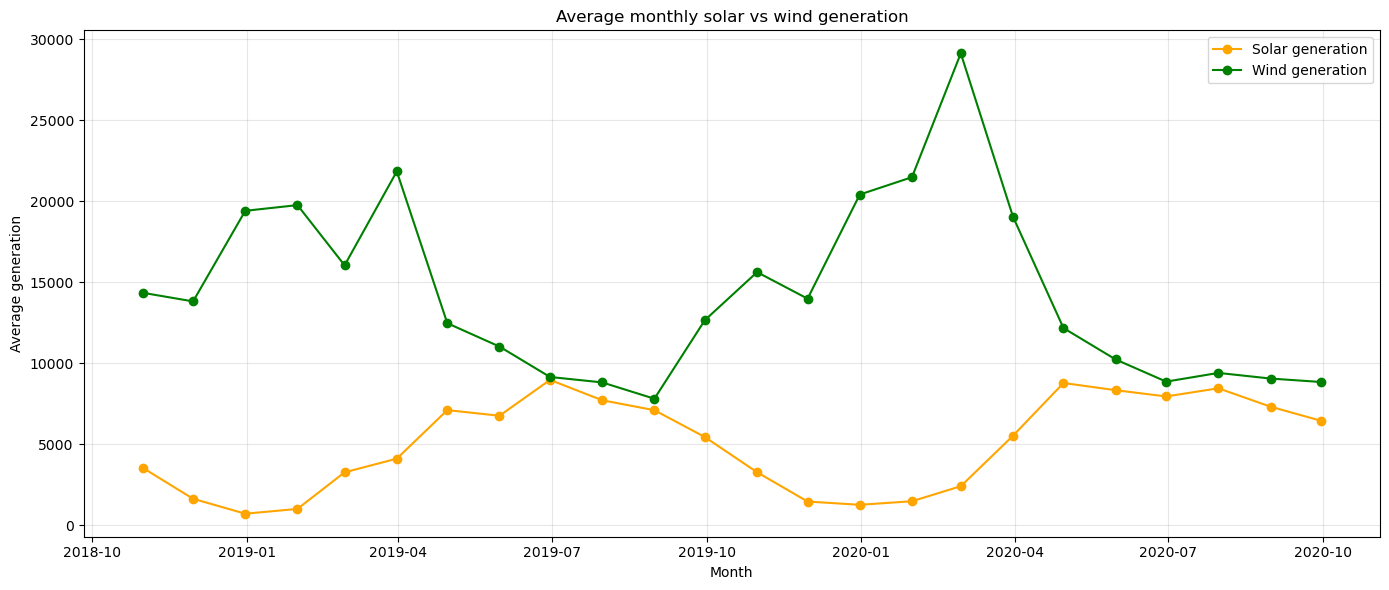

In [62]:
# Make a copy
df_plot = df_final.copy()

# Ensure utc_timestamp is datetime
if not is_datetime64_any_dtype(df_plot["utc_timestamp"]):
    df_plot["utc_timestamp"] = pd.to_datetime(
        df_plot["utc_timestamp"],
        utc=True,
        errors="coerce"
    )

# Columns to compare
solar_col = "DE_solar_generation_actual"
wind_col = "DE_wind_generation_actual"

# Drop missing values and sort by time
df_plot = df_plot.dropna(subset=["utc_timestamp", solar_col, wind_col]).sort_values("utc_timestamp")

# Set index and resample monthly averages
df_plot = df_plot.set_index("utc_timestamp")
monthly_avg = (
    df_plot[[solar_col, wind_col]]
    .resample("ME")
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(14, 6))
plt.plot(
    monthly_avg["utc_timestamp"],
    monthly_avg[solar_col],
    marker="o",
    linewidth=1.5,
    label="Solar generation",
    color="orange"
)
plt.plot(
    monthly_avg["utc_timestamp"],
    monthly_avg[wind_col],
    marker="o",
    linewidth=1.5,
    label="Wind generation",
    color="green"
)
plt.title("Average monthly solar vs wind generation")
plt.xlabel("Month")
plt.ylabel("Average generation")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2.6 Average monthly electricity demand over time

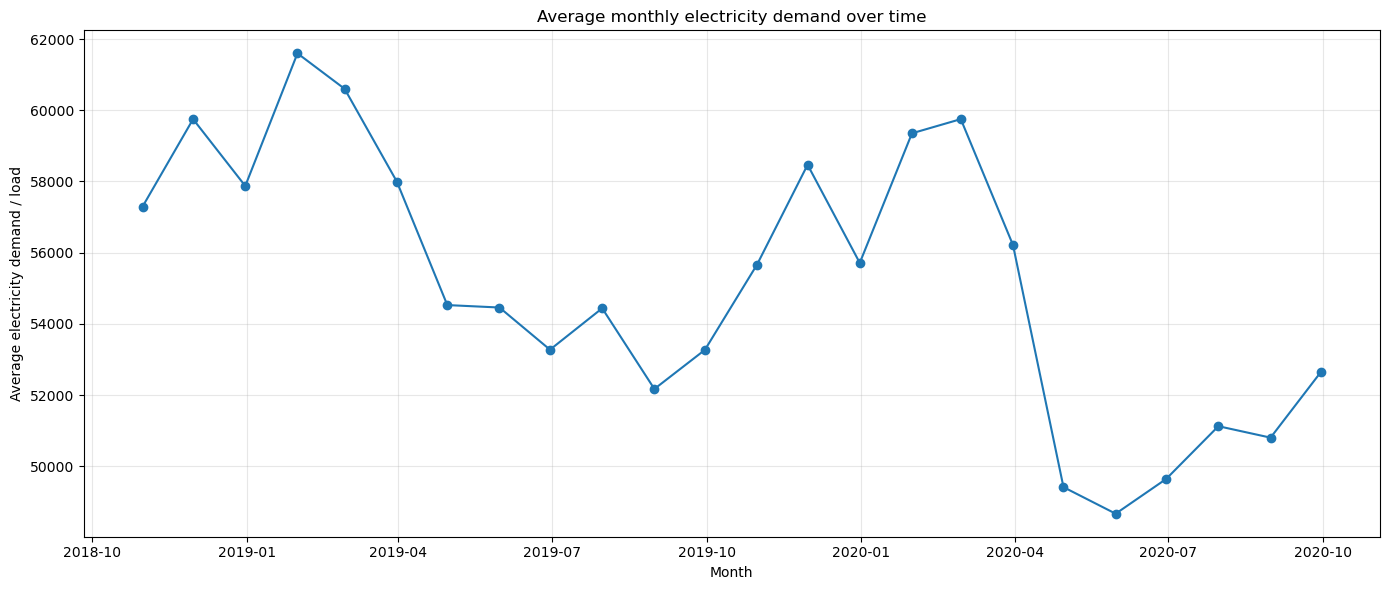

In [63]:
# Make a copy
df_plot = df_final.copy()

# Ensure utc_timestamp is datetime
if not is_datetime64_any_dtype(df_plot["utc_timestamp"]):
    df_plot["utc_timestamp"] = pd.to_datetime(
        df_plot["utc_timestamp"],
        utc=True,
        errors="coerce"
    )

# Demand column
demand_col = "DE_load_actual_entsoe_transparency"

# Drop missing values
df_plot = df_plot.dropna(subset=["utc_timestamp", demand_col])

# Sort by time
df_plot = df_plot.sort_values("utc_timestamp")

# Set utc_timestamp as index
df_plot = df_plot.set_index("utc_timestamp")

# Calculate average monthly electricity demand
monthly_demand = (
    df_plot[demand_col]
    .resample("ME")   # month end frequency
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_demand["utc_timestamp"],
    monthly_demand[demand_col],
    marker="o",
    linewidth=1.5
)

plt.title("Average monthly electricity demand over time")
plt.xlabel("Month")
plt.ylabel("Average electricity demand / load")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2.7 Average renewable energy production, electricity price and electricity demand by weekday

In [64]:
# Make a copy
df_plot = df_final.copy()

# Ensure utc_timestamp is datetime
if not is_datetime64_any_dtype(df_plot["utc_timestamp"]):
    df_plot["utc_timestamp"] = pd.to_datetime(
        df_plot["utc_timestamp"],
        utc=True,
        errors="coerce"
    )


#### Setup day names
day_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

# Extract date and day of week
df_plot["date"] = df_plot["utc_timestamp"].dt.date
df_plot["dayofweek"] = df_plot["utc_timestamp"].dt.dayofweek


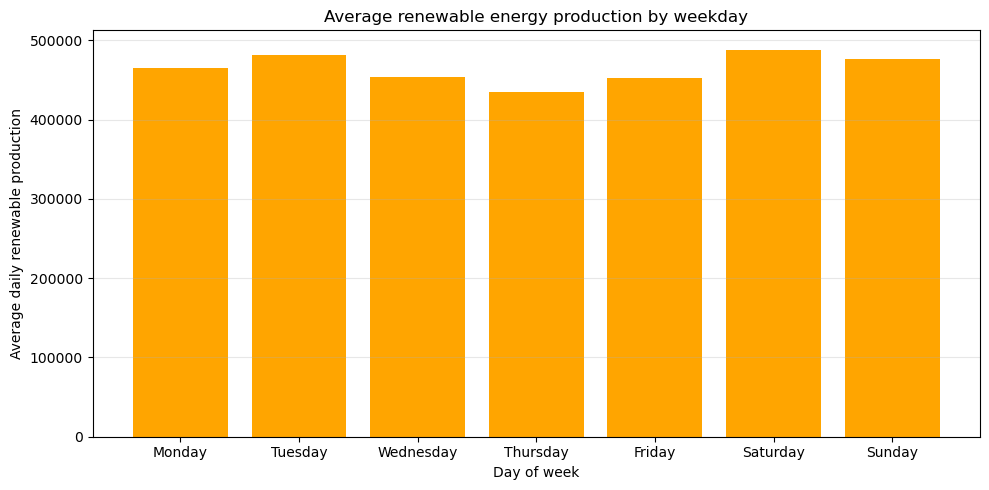

In [65]:
# Columns
solar_col = "DE_solar_generation_actual"
wind_col = "DE_wind_generation_actual"

# Create renewable production column: solar + wind
df_plot["renewable_generation"] = df_plot[solar_col] + df_plot[wind_col]

# Sum hourly renewable generation per day
daily_renewable = (
    df_plot
    .groupby(["date", "dayofweek"])["renewable_generation"]
    .sum()
    .reset_index()
)

# Average daily renewable production from Monday to Sunday
avg_daily_renewable = (
    daily_renewable
    .groupby("dayofweek")["renewable_generation"]
    .mean()
    .reset_index()
)

avg_daily_renewable["day_name"] = avg_daily_renewable["dayofweek"].map(day_names)

# Plot
plt.figure(figsize=(10, 5))

plt.bar(
    avg_daily_renewable["day_name"],
    avg_daily_renewable["renewable_generation"],
    color="orange"
)

plt.title("Average renewable energy production by weekday")
plt.xlabel("Day of week")
plt.ylabel("Average daily renewable production")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

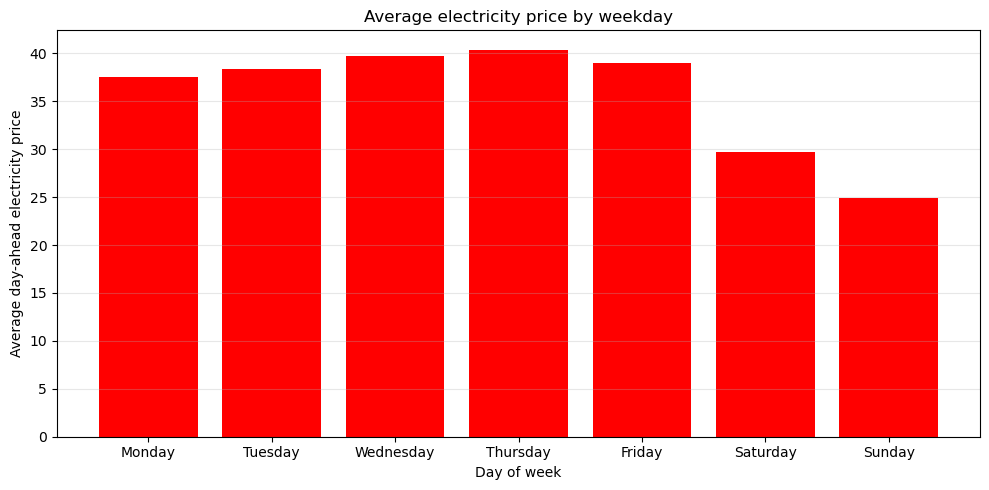

In [66]:
# Target column
price_col = "DE_LU_price_day_ahead"

# Calculate average price by weekday
avg_price_by_weekday = (
    df_plot
    .groupby("dayofweek")[price_col]
    .mean()
    .reset_index()
)

avg_price_by_weekday["day_name"] = avg_price_by_weekday["dayofweek"].map(day_names)

# Plot
plt.figure(figsize=(10, 5))
plt.bar(avg_price_by_weekday["day_name"], avg_price_by_weekday[price_col], color="red")
plt.title("Average electricity price by weekday")
plt.xlabel("Day of week")
plt.ylabel("Average day-ahead electricity price")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

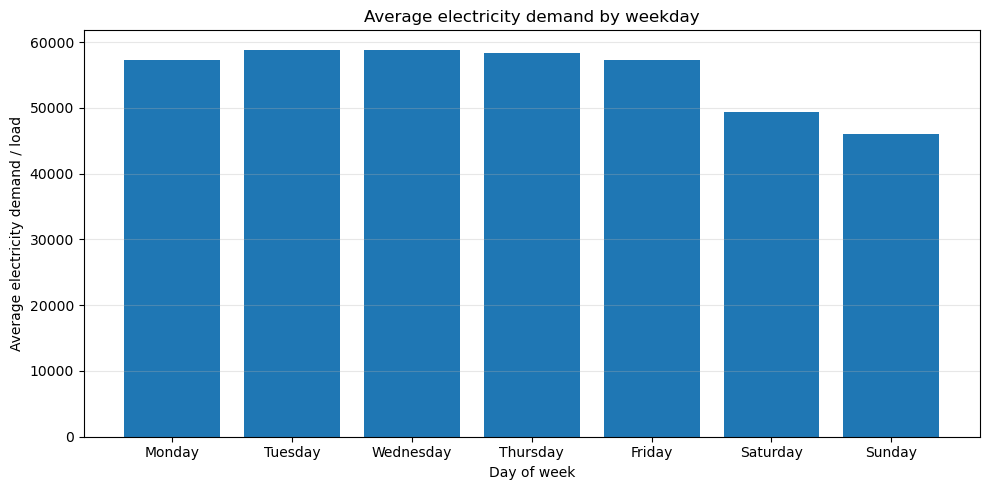

In [67]:
# Demand column
demand_col = "DE_load_actual_entsoe_transparency"

# Calculate average demand by weekday
avg_demand_by_weekday = (
    df_plot
    .groupby("dayofweek")[demand_col]
    .mean()
    .reset_index()
)

avg_demand_by_weekday["day_name"] = avg_demand_by_weekday["dayofweek"].map(day_names)

# Plot
plt.figure(figsize=(10, 5))
plt.bar(avg_demand_by_weekday["day_name"], avg_demand_by_weekday[demand_col])
plt.title("Average electricity demand by weekday")
plt.xlabel("Day of week")
plt.ylabel("Average electricity demand / load")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()